In [69]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})

DATA_PATH = '/data/SO3/edavenport/tpose24/oct2012_TP6Vel_3month/PROF_eq/FCTD_1min_model.nc'

In [70]:
ds = xr.open_dataset(DATA_PATH)

lons  = ds['prof_lon'].values
lats  = ds['prof_lat'].values
depths = ds['prof_depth'].values            # (62,) metres
dates_raw = ds['prof_YYYYMMDD'].values      # YYYYMMDD float
times_raw = ds['prof_HHMMSS'].values        # HHMMSS float

T      = ds['prof_T'].values.astype(float)
S      = ds['prof_S'].values.astype(float)
Testim = ds['prof_Testim'].values.astype(float)
Sestim = ds['prof_Sestim'].values.astype(float)

# Build datetime index from YYYYMMDD + HHMMSS
def parse_datetime(yyyymmdd, hhmmss):
    d = int(yyyymmdd)
    t = int(hhmmss)
    yr, mo, dy = d // 10000, (d % 10000) // 100, d % 100
    hh, mm, ss = t // 10000, (t % 10000) // 100, t % 100
    return pd.Timestamp(yr, mo, dy, hh, mm, ss)

timestamps = np.array([parse_datetime(d, t) for d, t in zip(dates_raw, times_raw)])

t_all  = timestamps
T_all  = T          # (n_prof, 62)
S_all  = S
Te_all = Testim + T_all - T_all
Se_all = Sestim + S_all - S_all

print(f'Profiles: {len(t_all)}  |  Period: {t_all[0].date()} – {t_all[-1].date()}')
print(f'Depth levels: {len(depths)}  ({depths[0]:.0f}–{depths[-1]:.0f} m)')
print(f'Approx sampling: {len(t_all) / 91:.0f} profiles/day')

Profiles: 34166  |  Period: 2012-10-10 – 2012-11-02
Depth levels: 341  (10–350 m)
Approx sampling: 375 profiles/day


In [71]:
dT = T_all - Te_all   # obs - model
dS = S_all - Se_all             # negative = depth below surface

T = t_all   # x-axis
Z = -depths  

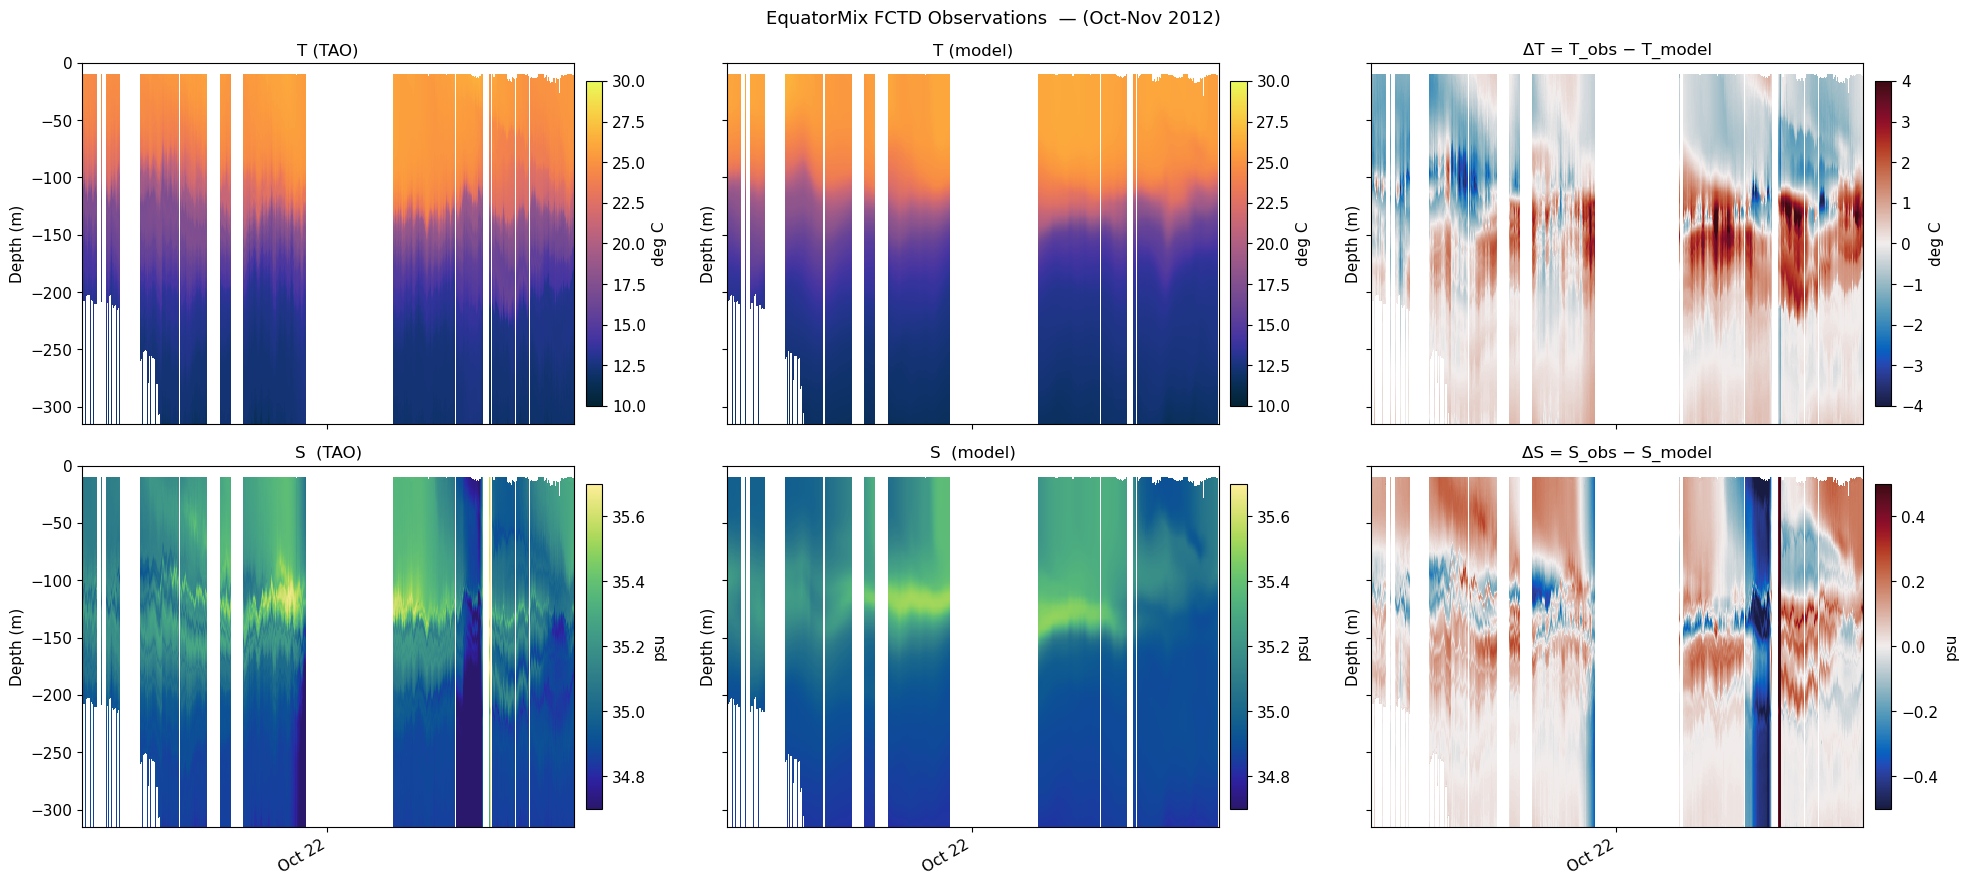

Saved fig1_140W_hovm_FCTD_1min.png


In [72]:
def hovm(ax, data, T, Z, cmap, vmin, vmax, label, title):
    """Hovmöller (time x depth) pcolor helper."""
    im = ax.pcolormesh(T, Z, data.T, cmap=cmap,
                       vmin=vmin, vmax=vmax, shading='auto')
    ax.set_ylabel('Depth (m)')
    ax.set_title(title)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    cb = plt.colorbar(im, ax=ax, pad=0.02, shrink=0.9)
    cb.set_label(label)
    return im

fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharex=True, sharey=True)
fig.suptitle('EquatorMix FCTD Observations  — (Oct-Nov 2012)', fontsize=13, y=0.98)

hovm(axes[0,0], T_all, T, Z, cmo.thermal, 10, 30, 'deg C', 'T (TAO)')
hovm(axes[1,0], S_all, T, Z, cmo.haline, 34.7, 35.7, 'psu', 'S  (TAO)')
hovm(axes[0,1], Te_all, T, Z, cmo.thermal, 10, 30, 'deg C', 'T (model)')
hovm(axes[1,1], Se_all, T, Z, cmo.haline, 34.7, 35.7, 'psu', 'S  (model)')
hovm(axes[0,2], dT, T, Z, cmo.balance, -4, 4, 'deg C', 'ΔT = T_obs − T_model')
hovm(axes[1,2], dS, T, Z, cmo.balance, -0.5, 0.5, 'psu', 'ΔS = S_obs − S_model')

for ax in axes.flatten():
    ax.set_ylim([-315, 0])
    ax.set_xlim([T[0], T[-1]])
    
fig.tight_layout()
plt.savefig('EquatorMix_comparison/fig1_140W_hovm_FCTD_1min.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1_140W_hovm_FCTD_1min.png')

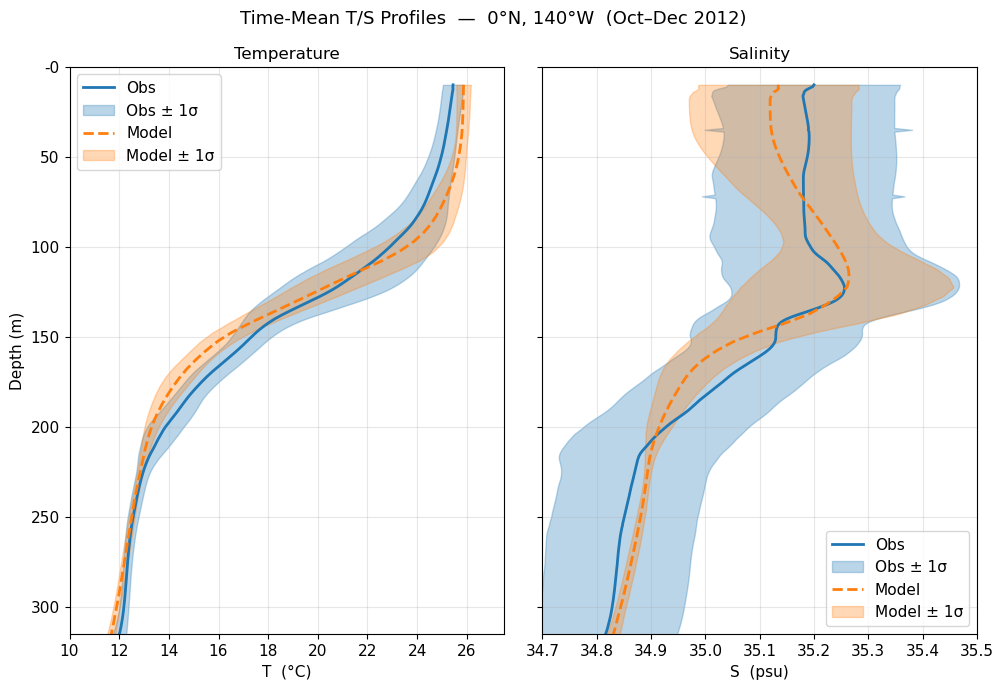

Saved fig2_mean_profiles.png


In [74]:
T_mean  = np.nanmean(T_all,  axis=0)
S_mean  = np.nanmean(S_all,  axis=0)
Te_mean = np.nanmean(Te_all, axis=0)
Se_mean = np.nanmean(Se_all, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
fig.suptitle('Time-Mean T/S Profiles  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

# T and its std dev
axes[0].plot(T_mean,  Z, color='C0', lw=2,   label='Obs')
axes[0].fill_betweenx(Z, T_mean - np.nanstd(T_all, axis=0), T_mean + np.nanstd(T_all, axis=0), color='C0', alpha=0.3, label='Obs ± 1σ')
axes[0].plot(Te_mean, Z, color='C1', lw=2, ls='--', label='Model')
axes[0].fill_betweenx(Z, Te_mean - np.nanstd(Te_all, axis=0), Te_mean + np.nanstd(Te_all, axis=0), color='C1', alpha=0.3, label='Model ± 1σ')
axes[0].axvline(0, color='k', lw=0.7, ls=':')
axes[0].set_xlabel('T  (°C)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('Temperature')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim([10, 27.5])

# S
axes[1].plot(S_mean,  Z, color='C0', lw=2,   label='Obs')
axes[1].fill_betweenx(Z, S_mean - np.nanstd(S_all, axis=0), S_mean + np.nanstd(S_all, axis=0), color='C0', alpha=0.3, label='Obs ± 1σ')
axes[1].plot(Se_mean, Z, color='C1', lw=2, ls='--', label='Model')
axes[1].fill_betweenx(Z, Se_mean - np.nanstd(Se_all, axis=0), Se_mean + np.nanstd(Se_all, axis=0), color='C1', alpha=0.3, label='Model ± 1σ')
axes[1].axvline(0, color='k', lw=0.7, ls=':')
axes[1].set_xlabel('S  (psu)')
axes[1].set_title('Salinity')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([34.7, 35.5])

for ax in axes:
    ax.set_ylim([-315, 0])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{-y:.0f}'))

fig.tight_layout()
plt.savefig('EquatorMix_comparison/fig2_mean_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2_mean_profiles.png')